# MERIDIAN - Analysis Module 7: Demand Forecasting

## Business question
How many orders should each region expect over the next quarter? Framed as an inventory-planning input - a region trending upward needs more stock on hand than one that's flat or declining.

## A pattern repeated for the third time in this project
Forecasting 'the next 3 months from today' doesn't work here - UCI (UK) data stops in 2011 and Olist (Brazil) stops in 2018, so 'today' is meaningless for those regions. Just like cohort retention (Module 3) and RFM recency (Module 4), each region is forecast forward from **its own last observed month**, not a shared global 'now'. Worth stating plainly: this is the same underlying lesson applied a third time, not three unrelated fixes.

## Tool choice, documented
The original brief suggested Prophet or statsmodels. Prophet needs a C++ compiler backend that's genuinely fussy to install on Windows - given the real environment friction already hit earlier in this project (ODBC drivers, venv locations), it wasn't worth the added risk for a 'lite' forecasting module. Using statsmodels' Exponential Smoothing (Holt's linear trend method) instead - simpler to install, and appropriate given the short history available (roughly 2-3 years per region) doesn't support a more complex model reliably anyway.

## A known limitation, upfront
No seasonality is modeled (e.g. holiday shopping spikes) - deliberately kept simple given the limited history length for some regions (UCI and Olist each have only ~24 months of real data, not enough to reliably detect a yearly seasonal pattern). This is a trend-only forecast, framed as a starting point, not a production-grade demand model.

## Step 1 - Connect and load monthly order counts per region

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
orders = pd.read_sql("SELECT order_id, region, order_date FROM marts.fct_orders", engine)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders = orders.dropna(subset=['order_date'])

orders['order_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_counts = orders.groupby(['region', 'order_month'])['order_id'].nunique().rename('order_count')
print(f"{len(orders):,} orders across {orders['region'].nunique()} regions")
monthly_counts.groupby('region').agg(['count', 'min'])

159,120 orders across 5 regions


,count,min
region,,
BR,25,1
DE,36,39
GH,36,46
UK,25,1015
US,36,33


## Step 2 - Fit a forecast per region and project the next quarter

Each region's series only uses its own months - no mixing calendar ranges across regions, same principle as every earlier fix.

**A real issue was caught here, worth documenting.** An initial run produced an impossible negative forecast for Brazil. Investigation traced it to the real Olist dataset's well-documented final month, which is incomplete (data collection was cut off mid-month, so it looks like demand collapsed to almost nothing, when really the data just stops). A trend model has no way to know that's a collection artifact rather than genuine decline, so it extrapolated the 'crash' forward into negative territory. Fixed below by dropping an obviously-incomplete final period before fitting, using a documented heuristic (a period is treated as incomplete if it falls below 30% of the recent average) rather than hardcoding a fix specific to Brazil - the same check applies to every region, in case any other source has the same issue.

In [12]:
def trim_incomplete_tail(series, threshold=0.3, max_trim=3):
    """Iteratively drop trailing periods that look incomplete, one at a
    time, re-checking after each drop - a data-collection cutoff can span
    more than one final period (confirmed for real: Brazil's data cuts
    off across TWO months, not one - see PROJECT_LOG.md)."""
    trimmed = 0
    while len(series) >= 4 and trimmed < max_trim:
        recent_avg = series.iloc[-4:-1].mean()
        if series.iloc[-1] < threshold * recent_avg:
            print(f"  {series.name}: dropping {series.index[-1].strftime('%Y-%m')} "
                  f"(value={series.iloc[-1]:.0f}) vs recent average {recent_avg:.0f}")
            series = series.iloc[:-1]
            trimmed += 1
        else:
            break
    return series

forecasts = {}
histories = {}

for region in monthly_counts.index.get_level_values('region').unique():
    series = monthly_counts.xs(region, level='region').asfreq('MS').fillna(0)
    series.name = region
    histories[region] = series

    fit_series = trim_incomplete_tail(series)
    model = ExponentialSmoothing(fit_series, trend='add', seasonal=None, initialization_method='estimated')
    fit = model.fit()
    forecasts[region] = fit.forecast(3)

forecast_summary = pd.DataFrame({
    region: {'next_3_months_total': int(f.sum()), 'last_observed_month': histories[region].index[-1].strftime('%Y-%m')}
    for region, f in forecasts.items()
}).T
forecast_summary

  BR: dropping 2018-10 (value=4) vs recent average 4273
  BR: dropping 2018-09 (value=16) vs recent average 6324


,next_3_months_total,last_observed_month
BR,18893,2018-10
DE,174,2025-12
GH,155,2025-12
UK,6384,2011-12
US,169,2025-12


## Step 3 - Visualize history and forecast, per region

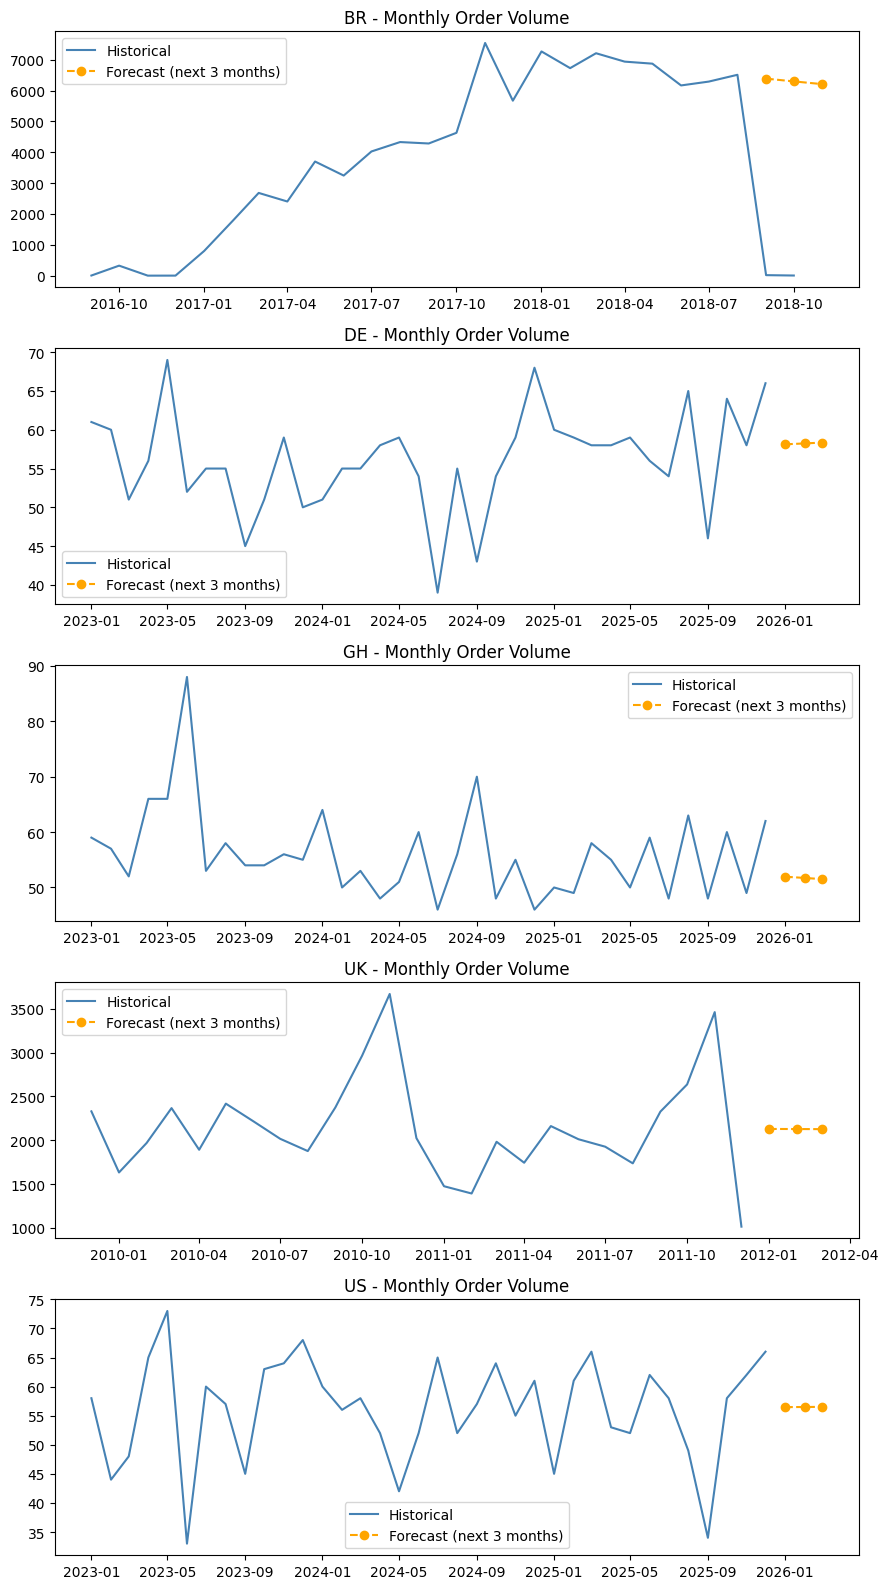

In [13]:
regions = list(histories.keys())
fig, axes = plt.subplots(len(regions), 1, figsize=(9, 3.2 * len(regions)), sharex=False)

for ax, region in zip(axes, regions):
    hist = histories[region]
    fc = forecasts[region]
    ax.plot(hist.index, hist.values, label='Historical', color='steelblue')
    ax.plot(fc.index, fc.values, label='Forecast (next 3 months)', color='orange', linestyle='--', marker='o')
    ax.set_title(f'{region} - Monthly Order Volume')
    ax.legend()

plt.tight_layout()
plt.savefig('demand_forecast_by_region.png', dpi=120)
plt.show()

## Findings - fill this in with your actual numbers

_After running the cells above: which regions show a rising trend, and which are flat or declining? Do any forecasts look implausible (e.g. predicting negative orders, or a trend that clearly doesn't match the visible history)? Write 2-3 sentences, then carry into `PROJECT_LOG.md`._

## Known limitation - worth stating explicitly
This is a trend-only extrapolation from a short history (roughly 2-3 years per region) with no seasonality, no external factors (marketing campaigns, holidays, competitor activity), and no confidence interval shown. Treat this as a rough planning input to sanity-check against, not a number to commit inventory budget to directly.

## Step 4 - Export results to SQL Server for Power BI

Writes two tables: a long-format monthly series (history + forecast combined, with a flag distinguishing them - ready for a Power BI line chart), and a summary table with the headline 3-month totals per region.

In [14]:
export_rows = []
for region in histories:
    for date, value in histories[region].items():
        export_rows.append({'region': region, 'month': date, 'value': float(value), 'is_forecast': False})
    for date, value in forecasts[region].items():
        export_rows.append({'region': region, 'month': date, 'value': float(value), 'is_forecast': True})

forecast_monthly_export = pd.DataFrame(export_rows)
forecast_monthly_export.to_sql('demand_forecast_monthly', engine, schema='reporting', if_exists='replace', index=False)
print(f"Exported {len(forecast_monthly_export):,} rows to reporting.demand_forecast_monthly")

forecast_summary_export = forecast_summary.reset_index().rename(columns={'index': 'region'})
forecast_summary_export.to_sql('demand_forecast_summary', engine, schema='reporting', if_exists='replace', index=False)
print(f"Exported {len(forecast_summary_export):,} rows to reporting.demand_forecast_summary")

Exported 174 rows to reporting.demand_forecast_monthly
Exported 5 rows to reporting.demand_forecast_summary
